# Circuit Visualization

Two views of the discovered arithmetic circuits from EAP-IG:

- **Option 2** — NetworkX directed graph: nodes laid out by layer/head, edges colored by Q/K/V type and weighted by attribution score
- **Option 3** — Score heatmap: layer × layer view of aggregated edge attribution scores across the full (unthresholded) graph

> **Prerequisites**
> ```bash
> pip install networkx matplotlib seaborn
> git lfs pull   # needed to resolve eap_graph.pt from the LFS pointer
> ```
> The `.pt` files in `analysis_output/` are git-lfs pointers (~130 bytes on disk). Run `git lfs pull` from the repo root to download the real tensors (~16 MB each). The notebook falls back to C_arith.json node names if the `.pt` file is missing or is still a pointer.

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
# Pick a model run and dataset to visualize
MODEL_RUN  = "analysis_output_Llama-2-7B_smaller_test"   # folder inside analysis_output/
DATASET    = "english"                                    # numeric | english | spanish

# NetworkX graph controls
TOP_K_EDGES      = 150     # show only the top-K circuit edges by |score| (keeps the plot readable)
MIN_PENWIDTH     = 0.4     # thinnest edge line
MAX_PENWIDTH     = 6.0     # thickest edge line
FIGSIZE_GRAPH    = (28, 14)

# Heatmap controls
HEATMAP_AGG      = "max"   # how to aggregate scores per layer-pair: "max" | "mean" | "sum"
HEATMAP_ABS      = True    # use |score| before aggregating
FIGSIZE_HEATMAP  = (14, 11)

# ── Paths (auto-derived) ─────────────────────────────────────────────────────
import pathlib
ROOT       = pathlib.Path(".").resolve()
RUN_DIR    = ROOT / "analysis_output" / MODEL_RUN / DATASET
PT_PATH    = RUN_DIR / "eap_graph.pt"
JSON_PATH  = RUN_DIR / "C_arith.json"
print(f"Run dir : {RUN_DIR}")
print(f".pt size: {PT_PATH.stat().st_size:,} bytes  {'← LFS pointer, run git lfs pull' if PT_PATH.stat().st_size < 500 else '← real file'}")

Run dir : /Users/sanapandey/arithmetic-dataset/analysis_output/analysis_output_Llama-2-7B_smaller_test/english
.pt size: 16,489,779 bytes  ← real file


In [2]:
# ── Load the graph ───────────────────────────────────────────────────────────
import json, re
import numpy as np
import torch

def _is_lfs_pointer(path):
    """Return True if the file is a git-lfs pointer (not the real binary)."""
    try:
        with open(path, "rb") as f:
            header = f.read(32)
        return header.startswith(b"version https://git-lfs")
    except Exception:
        return False

# ── Try loading from .pt ──────────────────────────────────────────────────────
pt_data = None
if PT_PATH.exists() and not _is_lfs_pointer(PT_PATH):
    print("Loading eap_graph.pt …")
    pt_data = torch.load(str(PT_PATH), map_location="cpu")
    cfg        = pt_data["cfg"]
    src_nodes  = pt_data["src_nodes"]
    dst_nodes  = pt_data["dst_nodes"]
    scores_mat = pt_data["edges_scores"].float().numpy()   # [n_forward, n_backward]
    in_graph   = pt_data["edges_in_graph"].numpy()         # bool [n_forward, n_backward]
    n_layers   = cfg["n_layers"]
    n_heads    = cfg["n_heads"]
    print(f"  cfg     : n_layers={n_layers}, n_heads={n_heads}")
    print(f"  scores  : {scores_mat.shape}")
    print(f"  circuit : {in_graph.sum():,} edges included")
else:
    print("⚠  eap_graph.pt is a git-lfs pointer (or missing).")
    print("   Run `git lfs pull` to download the real file.")
    print("   Falling back to C_arith.json for node names (no edge scores available).")
    with open(JSON_PATH) as f:
        c_arith = json.load(f)
    circuit_nodes = c_arith.get("per_format", {}).get(DATASET, c_arith.get("combined", []))
    # Infer n_layers / n_heads from node names
    layers = [int(re.search(r"\d+", n).group()) for n in circuit_nodes
              if n not in ("input", "logits") and re.search(r"\d+", n)]
    n_layers = max(layers) + 1 if layers else 32
    heads = [int(n.split(".")[1][1:]) for n in circuit_nodes if n.startswith("a")]
    n_heads = max(heads) + 1 if heads else 32
    pt_data = None
    cfg = {"n_layers": n_layers, "n_heads": n_heads}
    print(f"  Inferred: n_layers={n_layers}, n_heads={n_heads}")
    print(f"  Circuit nodes: {len(circuit_nodes)}")

Loading eap_graph.pt …
  cfg     : n_layers=32, n_heads=32
  scores  : (1057, 3105)
  circuit : 4,650 edges included


---
## Option 2 — NetworkX directed graph

Layout: layer index on the x-axis, head index on y-axis (attention heads stacked vertically, MLP block pinned below). Edge colour encodes Q/K/V input type; edge width encodes |score|.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Build the networkx graph ──────────────────────────────────────────────────
G = nx.DiGraph()

# Node layout positions: (x=layer, y=head_or_position)
MLP_Y    = -2          # MLPs sit below all attention heads
INPUT_X  = -1
LOGIT_X  = n_layers

def node_pos(name):
    if name == "input":
        return (INPUT_X, n_heads / 2)
    if name == "logits":
        return (LOGIT_X, n_heads / 2)
    if name.startswith("m"):
        return (int(name[1:]), MLP_Y)
    if name.startswith("a"):
        layer, head = name.split(".")
        return (int(layer[1:]), int(head[1:]))
    return (0, 0)

def node_color(name):
    if name in ("input", "logits"):  return "#f0c040"   # gold
    if name.startswith("m"):         return "#a8d8a8"   # green
    return "#a8c8f0"                                     # blue (attention)

QKV_COLORS = {"q": "#3a86ff", "k": "#ff6b6b", "v": "#06d6a0", None: "#888888"}

if pt_data is not None:
    # Build from .pt: iterate over the scores matrix
    # dst_nodes list: each entry is like 'a0.h0<q>' or 'm0' or 'logits'
    def parse_dst(dst):
        """Return (node_name, qkv_or_None)"""
        m = re.match(r"(.+)<([qkv])>$", dst)
        if m:
            return m.group(1), m.group(2)
        return dst, None

    # Collect all circuit edges with scores
    circuit_edges = []
    for si, src in enumerate(src_nodes):
        for di, dst_raw in enumerate(dst_nodes):
            if not in_graph[si, di]:
                continue
            dst, qkv = parse_dst(dst_raw)
            score = float(scores_mat[si, di])
            circuit_edges.append((src, dst, qkv, score))

    # Keep only top-K by |score|
    circuit_edges.sort(key=lambda x: abs(x[3]), reverse=True)
    display_edges = circuit_edges[:TOP_K_EDGES]

    # Add nodes that appear in displayed edges
    used_nodes = set()
    for src, dst, _, _ in display_edges:
        used_nodes.add(src); used_nodes.add(dst)
    for name in used_nodes:
        G.add_node(name, pos=node_pos(name), color=node_color(name))

    # Normalise edge widths
    top_scores = [abs(e[3]) for e in display_edges]
    score_min, score_max = min(top_scores), max(top_scores)
    def pen_width(s):
        if score_max == score_min:
            return (MIN_PENWIDTH + MAX_PENWIDTH) / 2
        norm = (abs(s) - score_min) / (score_max - score_min)
        return MIN_PENWIDTH + norm * (MAX_PENWIDTH - MIN_PENWIDTH)

    for src, dst, qkv, score in display_edges:
        G.add_edge(src, dst, qkv=qkv, score=score,
                   width=pen_width(score),
                   color=QKV_COLORS[qkv])

else:
    # No .pt: build node-only graph from C_arith.json
    for name in circuit_nodes:
        G.add_node(name, pos=node_pos(name), color=node_color(name))
    print("No .pt loaded — graph shows nodes only (no edge scores).")

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges (top-{TOP_K_EDGES} shown)")

Graph: 61 nodes, 140 edges (top-150 shown)


Saved → /Users/sanapandey/arithmetic-dataset/analysis_output/analysis_output_Llama-2-7B_smaller_test/english/circuit_graph.png


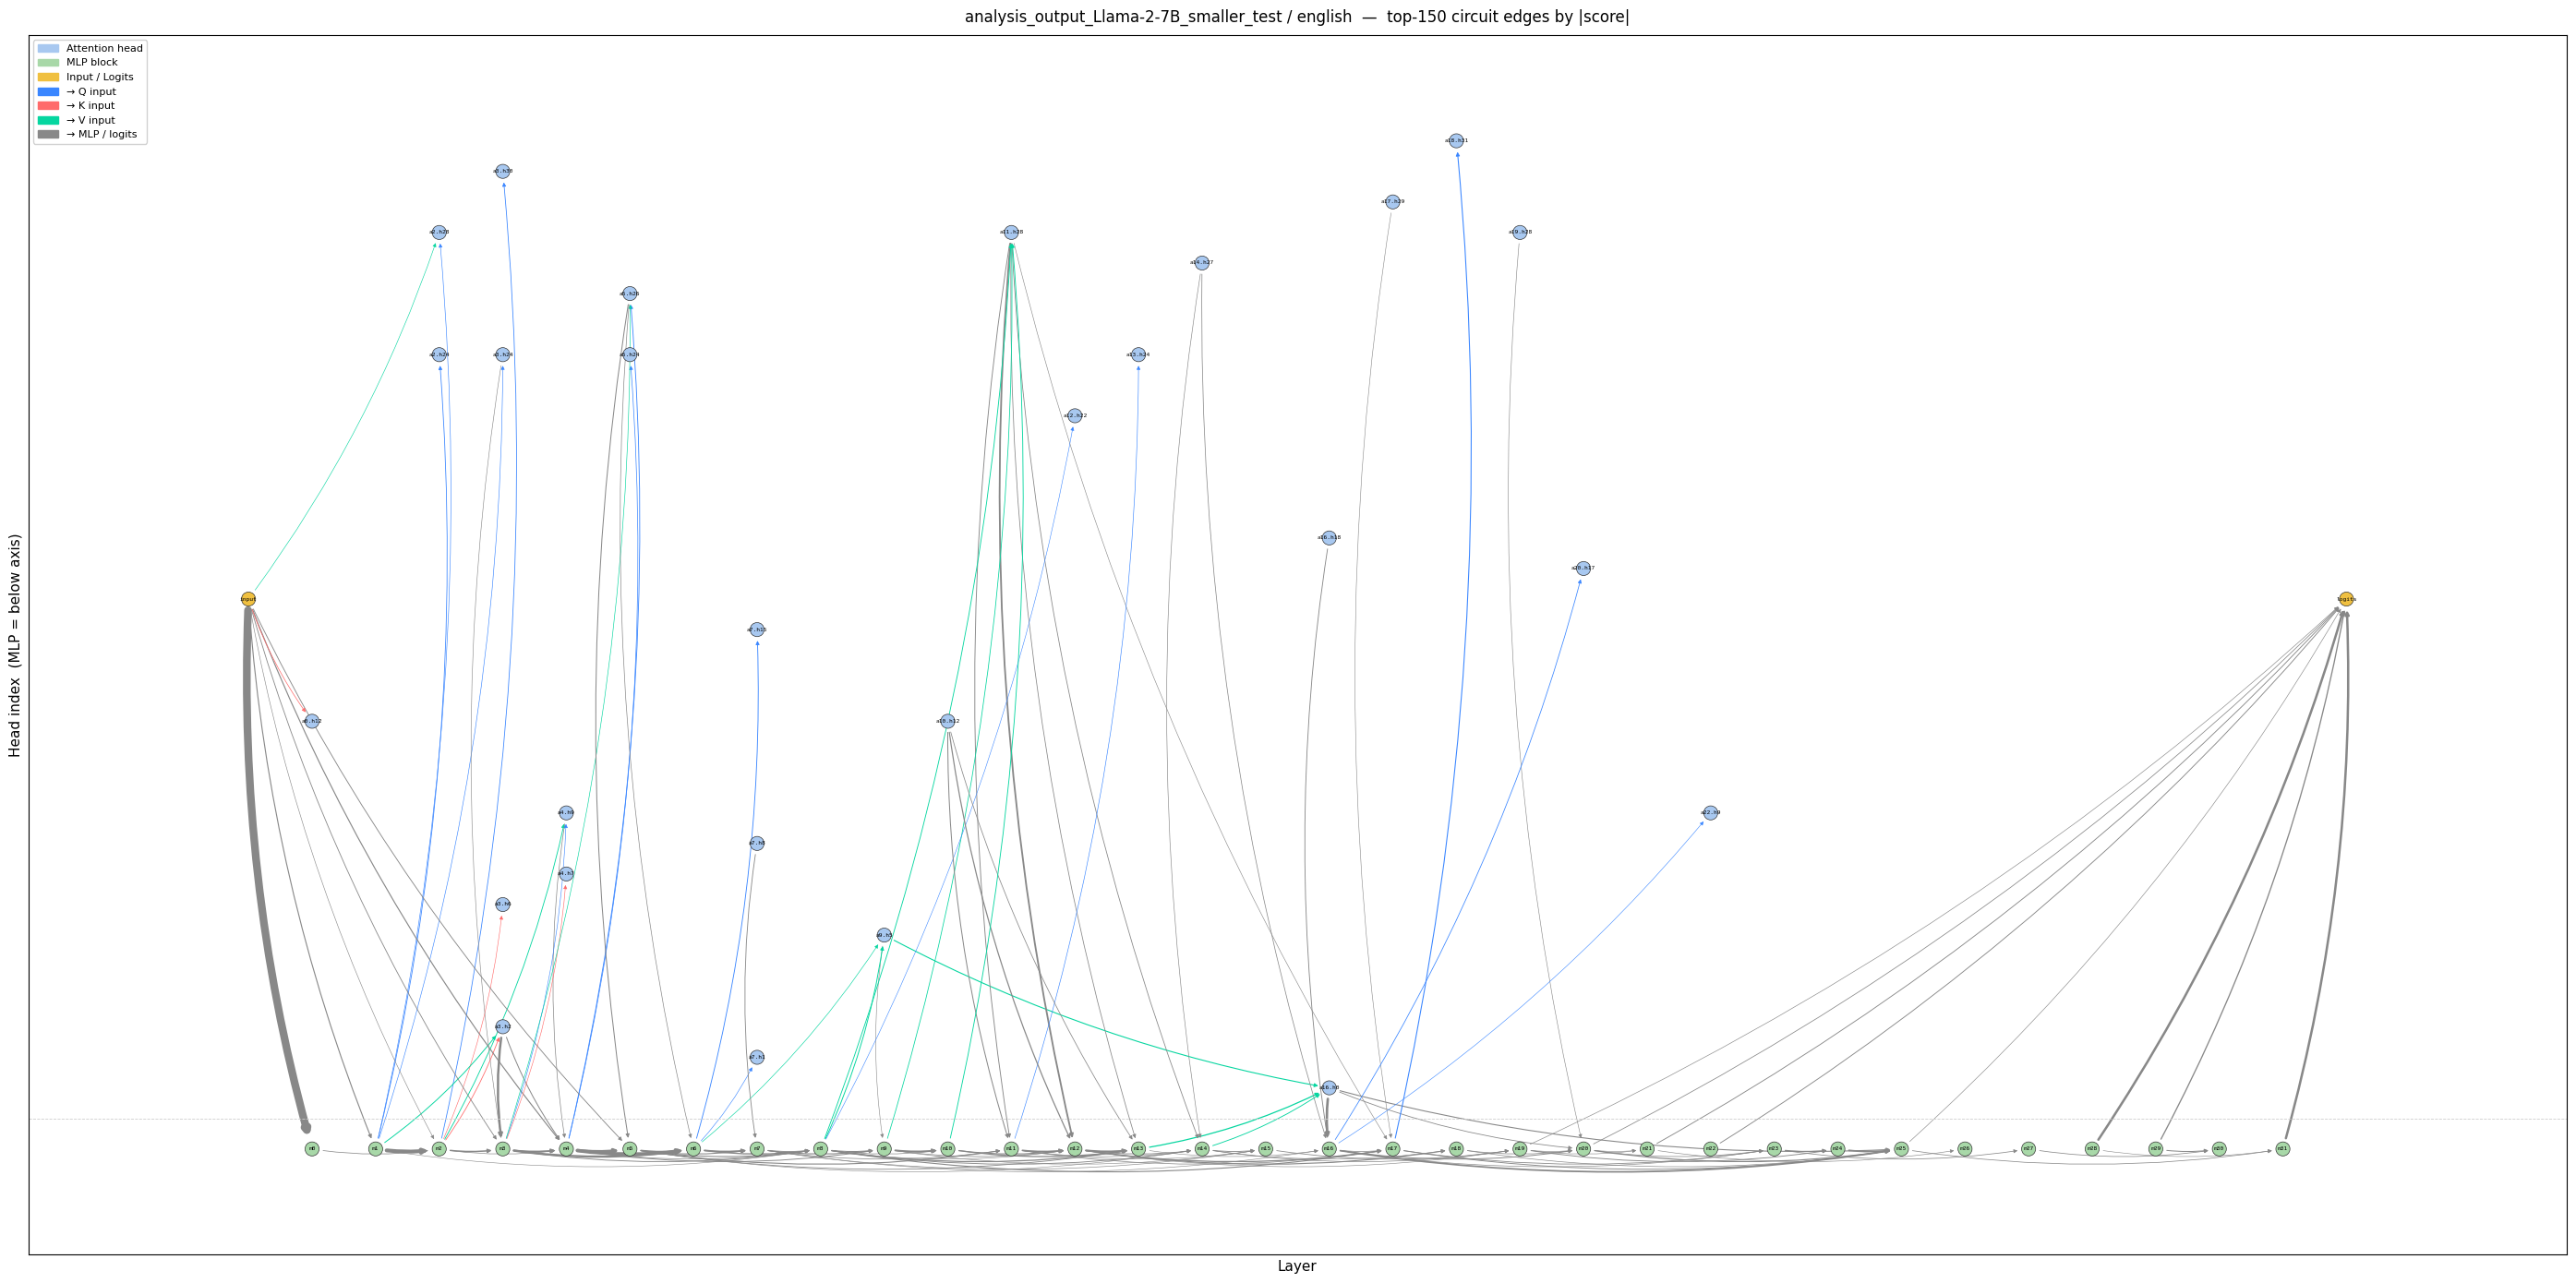

In [4]:
# ── Draw ──────────────────────────────────────────────────────────────────────
pos    = nx.get_node_attributes(G, "pos")
colors = [G.nodes[n]["color"] for n in G.nodes]

if G.number_of_edges() > 0:
    edge_colors = [G.edges[e]["color"] for e in G.edges]
    edge_widths = [G.edges[e]["width"] for e in G.edges]
else:
    edge_colors, edge_widths = [], []

fig, ax = plt.subplots(figsize=FIGSIZE_GRAPH)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=120,
                       linewidths=0.5, edgecolors="#333", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=4.5, font_family="monospace", ax=ax)
if G.number_of_edges() > 0:
    nx.draw_networkx_edges(G, pos,
                           edge_color=edge_colors, width=edge_widths,
                           arrows=True, arrowsize=6,
                           connectionstyle="arc3,rad=0.08",
                           ax=ax)

# Axis labels
ax.set_xlabel("Layer", fontsize=11)
ax.set_ylabel("Head index  (MLP = below axis)", fontsize=11)
ax.axhline(y=-1, color="#ccc", linewidth=0.6, linestyle="--")
ax.set_xticks(range(-1, n_layers + 1))
ax.set_xticklabels(["in"] + list(range(n_layers)) + ["logits"], fontsize=7)

# Legend
legend_handles = [
    mpatches.Patch(color="#a8c8f0", label="Attention head"),
    mpatches.Patch(color="#a8d8a8", label="MLP block"),
    mpatches.Patch(color="#f0c040", label="Input / Logits"),
    mpatches.Patch(color=QKV_COLORS["q"], label="→ Q input"),
    mpatches.Patch(color=QKV_COLORS["k"], label="→ K input"),
    mpatches.Patch(color=QKV_COLORS["v"], label="→ V input"),
    mpatches.Patch(color=QKV_COLORS[None], label="→ MLP / logits"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.9)

title = f"{MODEL_RUN} / {DATASET}  —  top-{TOP_K_EDGES} circuit edges by |score|"
if pt_data is None:
    title += "  [nodes only — load .pt for edges]"
ax.set_title(title, fontsize=12, pad=10)
fig.tight_layout()
out = RUN_DIR / "circuit_graph.png"
fig.savefig(out, dpi=150)
print(f"Saved → {out}")
plt.show()

---
## Option 3 — Edge score heatmap

Aggregates all edge attribution scores into a **source layer × destination layer** matrix. Each cell shows the max (or mean/sum, configurable) of |score| across every edge between those two layers. This reveals the large-scale information flow structure without needing to resolve individual heads.

Because every node can feed any later node via the residual stream, the matrix is upper-triangular by construction — scores on or below the diagonal are zero (the graph enforces causality).

Saved → /Users/sanapandey/arithmetic-dataset/analysis_output/analysis_output_Llama-2-7B_smaller_test/english/circuit_score_heatmap.png


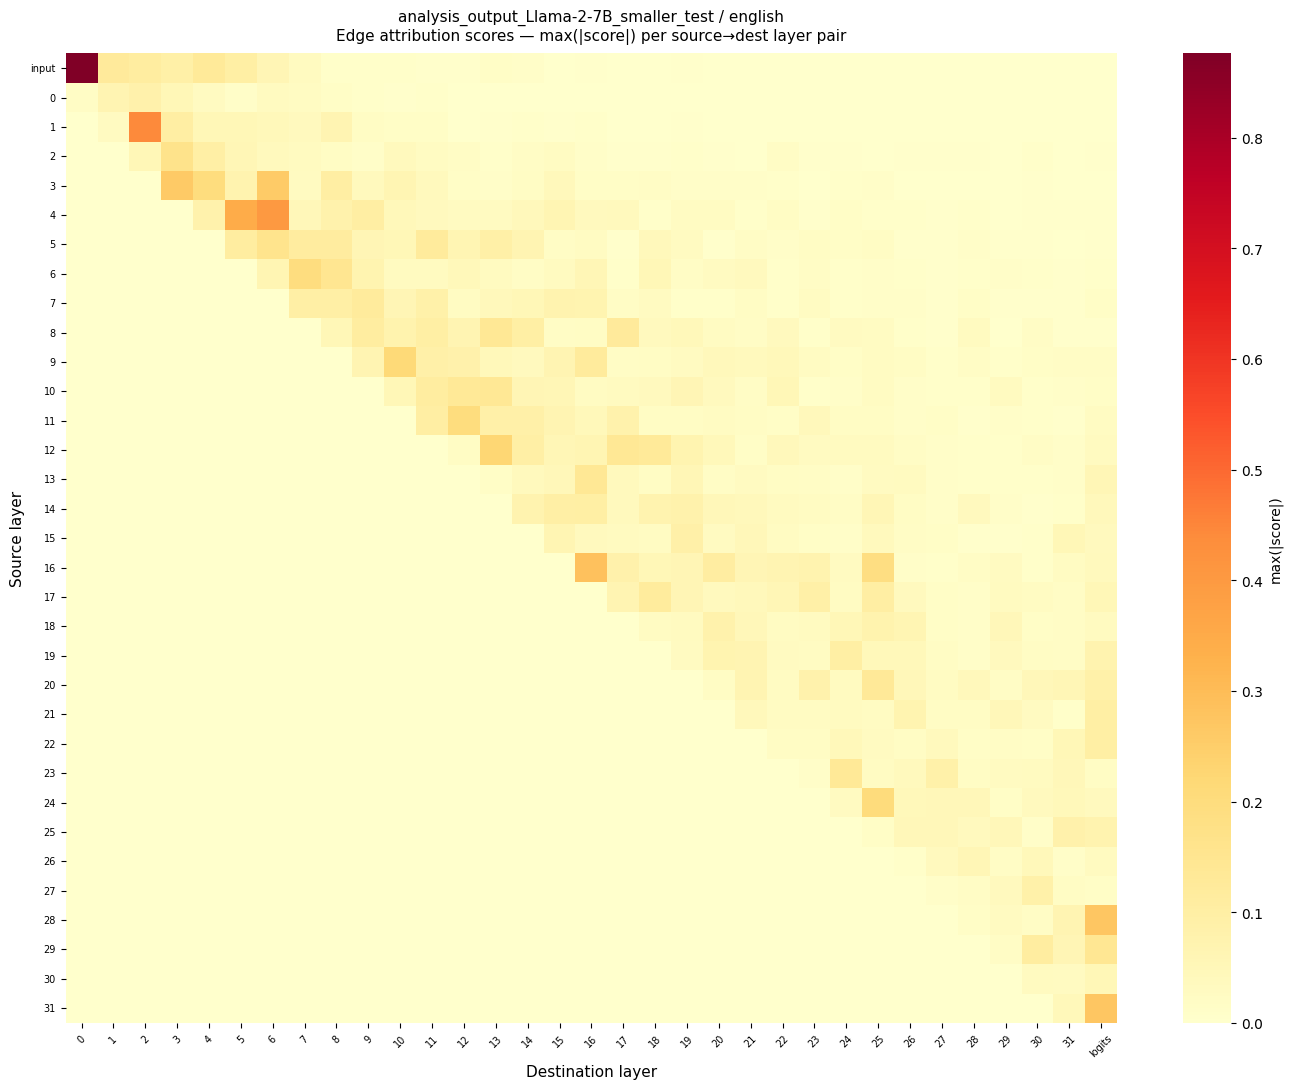

In [5]:
import seaborn as sns

if pt_data is None:
    print("Score heatmap requires the real eap_graph.pt. Run `git lfs pull` and restart.")
else:
    def node_layer(name):
        """Return the layer index for a node name, or a sentinel for input/logits."""
        if name == "input":  return -1
        if name == "logits": return n_layers
        return int(re.search(r"\d+", name).group())

    # Source layers: -1 (input), 0..n_layers-1
    # Dest layers  :  0..n_layers-1, n_layers (logits)
    src_layer_ids  = [node_layer(n) for n in src_nodes]
    dst_layer_ids  = [node_layer(parse_dst(n)[0]) for n in dst_nodes]

    src_labels = ["input"] + [str(i) for i in range(n_layers)]
    dst_labels = [str(i) for i in range(n_layers)] + ["logits"]
    src_idx_map = {v: i for i, v in enumerate([-1] + list(range(n_layers)))}
    dst_idx_map = {v: i for i, v in enumerate(list(range(n_layers)) + [n_layers])}

    n_src_l = len(src_labels)   # n_layers + 1
    n_dst_l = len(dst_labels)   # n_layers + 1

    agg_mat  = np.zeros((n_src_l, n_dst_l))
    count_mat = np.zeros((n_src_l, n_dst_l))

    vals = np.abs(scores_mat) if HEATMAP_ABS else scores_mat

    for si, sl in enumerate(src_layer_ids):
        for di, dl in enumerate(dst_layer_ids):
            v = vals[si, di]
            r, c = src_idx_map.get(sl), dst_idx_map.get(dl)
            if r is None or c is None:
                continue
            if HEATMAP_AGG == "max":
                agg_mat[r, c] = max(agg_mat[r, c], v)
            else:
                agg_mat[r, c]  += v
                count_mat[r, c] += 1

    if HEATMAP_AGG == "mean":
        with np.errstate(invalid="ignore"):
            agg_mat = np.where(count_mat > 0, agg_mat / count_mat, 0)

    # ── Draw ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)
    sns.heatmap(
        agg_mat,
        xticklabels=dst_labels,
        yticklabels=src_labels,
        cmap="YlOrRd",
        linewidths=0.0,
        ax=ax,
        cbar_kws={"label": f"{HEATMAP_AGG}({'|score|' if HEATMAP_ABS else 'score'})"},
    )
    ax.set_xlabel("Destination layer", fontsize=11)
    ax.set_ylabel("Source layer", fontsize=11)
    ax.set_title(
        f"{MODEL_RUN} / {DATASET}\n"
        f"Edge attribution scores — {HEATMAP_AGG}({'|score|' if HEATMAP_ABS else 'score'}) per source→dest layer pair",
        fontsize=11, pad=10
    )
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelrotation=0,  labelsize=7)
    fig.tight_layout()
    out = RUN_DIR / "circuit_score_heatmap.png"
    fig.savefig(out, dpi=150)
    print(f"Saved → {out}")
    plt.show()

---
## Bonus: top edges by attribution score

A ranked table of the highest-scoring edges in the circuit — useful for quickly spotting which specific connections the model relies on most.

In [7]:
if pt_data is None:
    print("Requires the real eap_graph.pt.")
else:
    ranked = sorted(circuit_edges, key=lambda x: abs(x[3]), reverse=True)
    print(f"Top 30 circuit edges by |score| ({len(circuit_edges):,} total in circuit):\n")
    print(f"{'Rank':>4}  {'|score|':>8}   {'score':>8}  {'edge'}")
    print("-" * 55)
    for i, (src, dst, qkv, score) in enumerate(ranked[:30], 1):
        edge_name = f"{src} → {dst}" + (f" <{qkv}>" if qkv else "")
        print(f"{i:>4}  {abs(score):>8.4f}  {score:>+8.4f}  {edge_name}")

Top 30 circuit edges by |score| (4,650 total in circuit):

Rank   |score|      score  edge
-------------------------------------------------------
   1    0.8760   +0.8760  input → m0
   2    0.4434   +0.4434  m1 → m2
   3    0.4011   -0.4011  m4 → m6
   4    0.3474   +0.3474  m4 → m5
   5    0.2864   +0.2864  a16.h0 → m16
   6    0.2734   +0.2734  m28 → logits
   7    0.2732   +0.2732  m31 → logits
   8    0.2632   +0.2632  a3.h2 → m3
   9    0.2588   -0.2588  m3 → m6
  10    0.2435   +0.2435  m4 → a5.h26 <v>
  11    0.2258   -0.2258  m12 → m13
  12    0.2152   -0.2152  m9 → m10
  13    0.2028   -0.2028  m24 → m25
  14    0.2015   +0.2015  m3 → m4
  15    0.2009   +0.2009  a11.h28 → m12
  16    0.1951   -0.1951  m6 → m7
  17    0.1920   -0.1920  m11 → m12
  18    0.1910   +0.1910  m3 → a4.h9 <v>
  19    0.1906   +0.1906  m16 → m25
  20    0.1655   +0.1655  m2 → m3
  21    0.1604   +0.1604  m5 → m6
  22    0.1479   +0.1479  m6 → m8
  23    0.1448   +0.1448  m29 → logits
  24    0.1405 